### 1. Initial Objectives and Predictive Modeling Results (Phase I)

#### 1.1. Initial Goal
The primary objective of Phase I was to **investigate the relationship** between aggregated daily meteorological data (temperature, precipitation) and semi-annual electricity consumption to **build a predictive model**. The core hypothesis was that weather features could serve as reliable predictors for consumption.

#### 1.2. Key Tasks
* Data cleaning, aggregation, and merging of weather and consumption data.
* Training a Random Forest Regressor model on the combined dataset.
* Assessing the correlation and feature importance of weather variables.

#### 1.3. Phase I Conclusion: No Dependency Found
The analysis revealed **no statistically significant or reliable dependency** between the aggregated semi-annual weather features and the semi-annual electricity consumption. The Random Forest model's performance was **extremely poor** ($R^2 \approx 0.00018$), confirming that the chosen predictors are not effective.

**Decision:** Given the lack of a predictive relationship on this dataset, the project pivots from **forecasting** to a **descriptive analysis** approach, which is more suited to the existing data structure and granularity.

---

### 2. Adjusted Goal and Descriptive Analysis Tasks (Phase II)

This phase focuses on preparing the cleaned consumption data for in-depth visualization and comparative analysis using an external business intelligence tool (Power BI).

#### 2.1. New Primary Goal
To perform a **complex descriptive and comparative analysis** of electricity consumption across the three cities to identify, quantify, and visualize the key trends, seasonal patterns, and consumption disparities.

#### 2.2. Key Tasks Completed in Python (Notebook Deliverables)
1.  **Data Structuring:** Finalizing data cleaning, transformation, and preparation steps.
2.  **Data Segmentation & Export:** Segmenting the processed dataset by city and **saving three final, clean datasets to CSV files** (e.g., `City1_Consumption.csv`, `City2_Consumption.csv`, `City3_Consumption.csv`) to serve as the data source for the subsequent analysis phase.

#### 2.3. Next Steps (Power BI Deliverables)
The analysis will continue in Power BI with the following objectives:
1.  **Comparative Analysis:** Create visualizations to compare the **total and average consumption** across the three cities.
2.  **Time Series Trend:** Plot the **long-term consumption trends** for each city to identify yearly growth or decline.
3.  **Seasonal Analysis:** Determine and visualize the difference in consumption between the two semi-annual periods (H1 vs. H2) for each city.

In [1]:
#the libraries installation
%pip install seaborn
%pip install requests

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [2]:
#import the libraries
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import requests


In [3]:
#load the dataset
url ='https://data.gov.lt/media/filer_public/87/2a/872af95e-f4fe-4c46-9d76-b2cdcd030c68/didmiesciai.csv'
df_energy=pd.read_csv(url, sep=';')
df_energy.head()


URLError: <urlopen error [Errno 11001] getaddrinfo failed>

In [ ]:
#clean the dataset
df_energy.dropna(inplace=True)
df_energy.fillna(0, inplace=True)
df_energy.drop_duplicates(inplace=True)
df_energy.isnull().sum()


REGIONAS     0
SUT_TIPAS    0
SUT_GAM      0
GV_TIPAS     0
GEN_GALIA    0
KWH01        0
KWH02        0
KWH03        0
KWH04        0
KWH05        0
KWH06        0
dtype: int64

In [ ]:
#explore the dataset
df_energy.info()
df_energy.describe()
df_energy.duplicated().sum()

<class 'pandas.core.frame.DataFrame'>
Index: 5317 entries, 21 to 1012774
Data columns (total 11 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   REGIONAS   5317 non-null   object 
 1   SUT_TIPAS  5317 non-null   object 
 2   SUT_GAM    5317 non-null   object 
 3   GV_TIPAS   5317 non-null   object 
 4   GEN_GALIA  5317 non-null   object 
 5   KWH01      5317 non-null   float64
 6   KWH02      5317 non-null   float64
 7   KWH03      5317 non-null   float64
 8   KWH04      5317 non-null   float64
 9   KWH05      5317 non-null   float64
 10  KWH06      5317 non-null   float64
dtypes: float64(6), object(5)
memory usage: 498.5+ KB


np.int64(0)

In [ ]:
#rename columns for easier access
df_energy.rename(columns={'REGIONAS':'Region', 'SUT_TIPAS':'Agreement_Type', 'SUT_GAM':'Provider', 'GV_TIPAS':'Generation_Type','GEN_GALIA':'Generation_Capacity'}, inplace=True)
df_energy.to_csv('cleaned_energy_data.csv', index=False)

In [ ]:
# melt the dataset for time series, keeping only KWH columns
value_vars = ['KWH01', 'KWH02', 'KWH03', 'KWH04', 'KWH05', 'KWH06']
id_vars = ['Region', 'Agreement_Type', 'Provider', 'Generation_Type','Generation_Capacity']
df_energy_melted = pd.melt(df_energy, id_vars=id_vars, value_vars=value_vars, var_name='PeriodCode')

# map PeriodCode to actual dates (use start dates of the half-years)
period_to_date = {
    'KWH01': '2022-01-01',
    'KWH02': '2022-07-01',
    'KWH03': '2023-01-01',
    'KWH04': '2023-07-01',
    'KWH05': '2024-01-01',
    'KWH06': '2024-07-01'
}
df_energy_melted['Date'] = pd.to_datetime(df_energy_melted['PeriodCode'].map(period_to_date))
df_energy_melted.head()





,Region,Agreement_Type,Provider,Generation_Type,Generation_Capacity,PeriodCode,value,Date
0,Vilniaus regionas,KV,T,Gaminantis vartotojas,"22,25",KWH01,545525.0,2022-01-01
1,Vilniaus regionas,KV,T,Gaminantis vartotojas,"19,72",KWH01,275888.0,2022-01-01
2,Vilniaus regionas,KV,T,Gaminantis vartotojas,"20,79",KWH01,197656.0,2022-01-01
3,Vilniaus regionas,KV,T,Gaminantis vartotojas,"19,8",KWH01,120302.0,2022-01-01
4,Vilniaus regionas,KV,T,Gaminantis vartotojas,"54,93",KWH01,43213.0,2022-01-01


In [ ]:
#save the dataset to a csv file
df_energy_melted.to_csv('melted_energy_data.csv', index=False)

In [ ]:
#get the weathaer historical date from API open-meteo
%pip install openmeteo-requests
%pip install requests-cache retry-requests numpy pandas

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
import openmeteo_requests
import pandas as pd
import requests_cache
from retry_requests import retry

# Setup the Open-Meteo API client with cache and retry on error
cache_session = requests_cache.CachedSession('.cache', expire_after = -1)
retry_session = retry(cache_session, retries = 5, backoff_factor = 0.2)
openmeteo = openmeteo_requests.Client(session = retry_session)

# Make sure all required weather variables are listed here
# The order of variables in hourly or daily is important to assign them correctly below
url = "https://archive-api.open-meteo.com/v1/archive"
params = {
	"latitude": 54.6892,
	"longitude": 25.2798,
	"start_date": "2022-01-01",
	"end_date": "2024-12-31",
	"daily": ["temperature_2m_mean", "wind_gusts_10m_max", "wind_speed_10m_max", "daylight_duration", "snowfall_sum", "temperature_2m_max", "temperature_2m_min", "precipitation_sum"],
	"timezone": "Europe/Moscow"
}
responses = openmeteo.weather_api(url, params=params)

# Process first location. Add a for-loop for multiple locations or weather models
response = responses[0]
print(f"Coordinates: {response.Latitude()}°N {response.Longitude()}°E")
print(f"Elevation: {response.Elevation()} m asl")
print(f"Timezone: {response.Timezone()}{response.TimezoneAbbreviation()}")
print(f"Timezone difference to GMT+0: {response.UtcOffsetSeconds()}s")

# Process daily data. The order of variables needs to be the same as requested.
daily = response.Daily()
daily_temperature_2m_mean = daily.Variables(0).ValuesAsNumpy()
daily_wind_speed_10m_max = daily.Variables(2).ValuesAsNumpy()
daily_daylight_duration = daily.Variables(3).ValuesAsNumpy()
daily_snowfall_sum = daily.Variables(4).ValuesAsNumpy()
daily_temperature_2m_max = daily.Variables(5).ValuesAsNumpy()
daily_temperature_2m_min = daily.Variables(6).ValuesAsNumpy()
daily_precipitation_sum = daily.Variables(7).ValuesAsNumpy()

daily_data = {"date": pd.date_range(
	start = pd.to_datetime(daily.Time(), unit = "s", utc = True),
	end =  pd.to_datetime(daily.TimeEnd(), unit = "s", utc = True),
	freq = pd.Timedelta(seconds = daily.Interval()),
	inclusive = "left"
)}

daily_data["temperature_2m_mean"] = daily_temperature_2m_mean
daily_data["wind_speed_10m_max"] = daily_wind_speed_10m_max
daily_data["daylight_duration"] = daily_daylight_duration
daily_data["snowfall_sum"] = daily_snowfall_sum
daily_data["temperature_2m_max"] = daily_temperature_2m_max
daily_data["temperature_2m_min"] = daily_temperature_2m_min
daily_data["precipitation_sum"] = daily_precipitation_sum

weather_Vilnius = pd.DataFrame(data = daily_data)
print("\nDaily data\n", weather_Vilnius)

Coordinates: 54.657291412353516°N 25.20709991455078°E
Elevation: 100.0 m asl
Timezone: b'Europe/Moscow'b'GMT+3'
Timezone difference to GMT+0: 10800s

Daily data
                           date  temperature_2m_mean  wind_speed_10m_max  \
0    2021-12-31 21:00:00+00:00             2.390833           23.770906   
1    2022-01-01 21:00:00+00:00            -1.921667           23.444265   
2    2022-01-02 21:00:00+00:00             3.140833           19.336390   
3    2022-01-03 21:00:00+00:00             3.528333           20.082708   
4    2022-01-04 21:00:00+00:00             1.401250           20.163212   
...                        ...                  ...                 ...   
1091 2024-12-26 21:00:00+00:00             2.222084           10.538843   
1092 2024-12-27 21:00:00+00:00             1.647083            9.587428   
1093 2024-12-28 21:00:00+00:00             1.565833           17.349236   
1094 2024-12-29 21:00:00+00:00             2.928333           25.035534   
1095 2024-12-

In [ ]:
#set the dates by half year periods
def get_period(date):
    if date.month <= 6:
        return f'{date.year}-01-01' 
    else:
        return f'{date.year}-07-01'

# create Period column
weather_Vilnius['Period'] = weather_Vilnius['date'].apply(get_period)

#aggregate data in dataframe weather_Vilnius by half year
weather_Vilnius_agg = weather_Vilnius.groupby('Period').agg({
    'temperature_2m_mean':'mean',
    'wind_speed_10m_max':'max',
    'daylight_duration':'mean',
    'snowfall_sum':'sum',
    'temperature_2m_max':'max',
    'temperature_2m_min':'min',
    'precipitation_sum':'sum'
}).reset_index()

weather_Vilnius_agg.head()


,Period,temperature_2m_mean,wind_speed_10m_max,daylight_duration,snowfall_sum,temperature_2m_max,temperature_2m_min,precipitation_sum
0,2021-07-01,2.390833,23.770906,26492.755859,0.000000,4.007500,-1.8425,0.900000
1,2022-01-01,5.929634,40.894478,46440.683594,62.580002,29.057501,-13.3425,461.899994
2,2022-07-01,9.842860,40.742077,42193.605469,44.380001,31.307501,-11.3925,341.200012
3,2023-01-01,7.007857,36.359997,46393.570312,77.419998,28.107500,-13.7425,362.100006
4,2023-07-01,10.974654,40.579521,42239.960938,43.119999,31.907499,-8.3925,493.700012


In [ ]:
#get the weather data for Kaunas

# Setup the Open-Meteo API client with cache and retry on error
cache_session = requests_cache.CachedSession('.cache', expire_after = -1)
retry_session = retry(cache_session, retries = 5, backoff_factor = 0.2)
openmeteo = openmeteo_requests.Client(session = retry_session)

# Make sure all required weather variables are listed here
# The order of variables in hourly or daily is important to assign them correctly below
url = "https://archive-api.open-meteo.com/v1/archive"
params = {
	"latitude": 54.9027,
	"longitude": 23.9096,
	"start_date": "2022-01-01",
	"end_date": "2024-12-31",
	"daily": ["temperature_2m_mean", "wind_gusts_10m_max", "wind_speed_10m_max", "daylight_duration", "snowfall_sum", "temperature_2m_max", "temperature_2m_min", "precipitation_sum"],
	"timezone": "Europe/Moscow"
}
responses = openmeteo.weather_api(url, params=params)

# Process first location. Add a for-loop for multiple locations or weather models
response = responses[0]
print(f"Coordinates: {response.Latitude()}°N {response.Longitude()}°E")
print(f"Elevation: {response.Elevation()} m asl")
print(f"Timezone: {response.Timezone()}{response.TimezoneAbbreviation()}")
print(f"Timezone difference to GMT+0: {response.UtcOffsetSeconds()}s")

# Process daily data. The order of variables needs to be the same as requested.
daily = response.Daily()
daily_temperature_2m_mean = daily.Variables(0).ValuesAsNumpy()
daily_wind_speed_10m_max = daily.Variables(2).ValuesAsNumpy()
daily_daylight_duration = daily.Variables(3).ValuesAsNumpy()
daily_snowfall_sum = daily.Variables(4).ValuesAsNumpy()
daily_temperature_2m_max = daily.Variables(5).ValuesAsNumpy()
daily_temperature_2m_min = daily.Variables(6).ValuesAsNumpy()
daily_precipitation_sum = daily.Variables(7).ValuesAsNumpy()

daily_data = {"date": pd.date_range(
	start = pd.to_datetime(daily.Time(), unit = "s", utc = True),
	end =  pd.to_datetime(daily.TimeEnd(), unit = "s", utc = True),
	freq = pd.Timedelta(seconds = daily.Interval()),
	inclusive = "left"
)}

daily_data["temperature_2m_mean"] = daily_temperature_2m_mean
daily_data["wind_speed_10m_max"] = daily_wind_speed_10m_max
daily_data["daylight_duration"] = daily_daylight_duration
daily_data["snowfall_sum"] = daily_snowfall_sum
daily_data["temperature_2m_max"] = daily_temperature_2m_max
daily_data["temperature_2m_min"] = daily_temperature_2m_min
daily_data["precipitation_sum"] = daily_precipitation_sum

weather_Kaunas = pd.DataFrame(data = daily_data)
print("\nDaily data\n", weather_Kaunas)

Coordinates: 54.868186950683594°N 23.928571701049805°E
Elevation: 76.0 m asl
Timezone: b'Europe/Moscow'b'GMT+3'
Timezone difference to GMT+0: 10800s

Daily data
                           date  temperature_2m_mean  wind_speed_10m_max  \
0    2021-12-31 21:00:00+00:00             2.527500           23.277834   
1    2022-01-01 21:00:00+00:00            -0.885000           35.364388   
2    2022-01-02 21:00:00+00:00             4.054583           21.288757   
3    2022-01-03 21:00:00+00:00             3.794166           19.829433   
4    2022-01-04 21:00:00+00:00             1.700417           21.647945   
...                        ...                  ...                 ...   
1091 2024-12-26 21:00:00+00:00             4.142084           10.823973   
1092 2024-12-27 21:00:00+00:00             3.223333           10.399576   
1093 2024-12-28 21:00:00+00:00             2.975417           15.528064   
1094 2024-12-29 21:00:00+00:00             4.010834           25.719852   
1095 2024-12-

In [ ]:
#set the dates by half year periods for Kaunas

# create Period column
weather_Kaunas['Period'] = weather_Kaunas['date'].apply(get_period)

#aggregate data in dataframe weather_Vilnius by half year
weather_Kaunas_agg = weather_Kaunas.groupby('Period').agg({
    'temperature_2m_mean':'mean',
    'wind_speed_10m_max':'max',
    'daylight_duration':'mean',
    'snowfall_sum':'sum',
    'temperature_2m_max':'max',
    'temperature_2m_min':'min',
    'precipitation_sum':'sum'
}).reset_index()

weather_Kaunas_agg.head()

,Period,temperature_2m_mean,wind_speed_10m_max,daylight_duration,snowfall_sum,temperature_2m_max,temperature_2m_min,precipitation_sum
0,2021-07-01,2.527500,23.277834,26340.142578,0.000000,4.152500,-2.8975,1.100000
1,2022-01-01,6.194927,42.183029,46468.996094,39.410000,29.752501,-11.5475,430.000000
2,2022-07-01,10.169269,35.406506,42182.761719,44.450001,30.202499,-11.6475,369.100006
3,2023-01-01,7.072585,42.259769,46421.441406,50.820000,27.752501,-11.5475,324.200012
4,2023-07-01,11.220412,41.414082,42229.539062,25.060001,32.752499,-6.7975,456.100006


In [ ]:
#get the weather data for Klaipeda

# Setup the Open-Meteo API client with cache and retry on error
cache_session = requests_cache.CachedSession('.cache', expire_after = -1)
retry_session = retry(cache_session, retries = 5, backoff_factor = 0.2)
openmeteo = openmeteo_requests.Client(session = retry_session)

# Make sure all required weather variables are listed here
# The order of variables in hourly or daily is important to assign them correctly below
url = "https://archive-api.open-meteo.com/v1/archive"
params = {
	"latitude": 55.7068,
	"longitude": 21.1391,
	"start_date": "2022-01-01",
	"end_date": "2024-12-31",
	"daily": ["temperature_2m_mean", "wind_gusts_10m_max", "wind_speed_10m_max", "daylight_duration", "snowfall_sum", "temperature_2m_max", "temperature_2m_min", "precipitation_sum"],
	"timezone": "Europe/Moscow"
}
responses = openmeteo.weather_api(url, params=params)

# Process first location. Add a for-loop for multiple locations or weather models
response = responses[0]
print(f"Coordinates: {response.Latitude()}°N {response.Longitude()}°E")
print(f"Elevation: {response.Elevation()} m asl")
print(f"Timezone: {response.Timezone()}{response.TimezoneAbbreviation()}")
print(f"Timezone difference to GMT+0: {response.UtcOffsetSeconds()}s")

# Process daily data. The order of variables needs to be the same as requested.
daily = response.Daily()
daily_temperature_2m_mean = daily.Variables(0).ValuesAsNumpy()
daily_wind_speed_10m_max = daily.Variables(2).ValuesAsNumpy()
daily_daylight_duration = daily.Variables(3).ValuesAsNumpy()
daily_snowfall_sum = daily.Variables(4).ValuesAsNumpy()
daily_temperature_2m_max = daily.Variables(5).ValuesAsNumpy()
daily_temperature_2m_min = daily.Variables(6).ValuesAsNumpy()
daily_precipitation_sum = daily.Variables(7).ValuesAsNumpy()

daily_data = {"date": pd.date_range(
	start = pd.to_datetime(daily.Time(), unit = "s", utc = True),
	end =  pd.to_datetime(daily.TimeEnd(), unit = "s", utc = True),
	freq = pd.Timedelta(seconds = daily.Interval()),
	inclusive = "left"
)}

daily_data["temperature_2m_mean"] = daily_temperature_2m_mean
daily_data["wind_speed_10m_max"] = daily_wind_speed_10m_max
daily_data["daylight_duration"] = daily_daylight_duration
daily_data["snowfall_sum"] = daily_snowfall_sum
daily_data["temperature_2m_max"] = daily_temperature_2m_max
daily_data["temperature_2m_min"] = daily_temperature_2m_min
daily_data["precipitation_sum"] = daily_precipitation_sum

weather_Klaipeda = pd.DataFrame(data = daily_data)
print("\nDaily data\n", weather_Klaipeda)

Coordinates: 55.71177291870117°N 21.219512939453125°E
Elevation: 10.0 m asl
Timezone: b'Europe/Moscow'b'GMT+3'
Timezone difference to GMT+0: 10800s

Daily data
                           date  temperature_2m_mean  wind_speed_10m_max  \
0    2021-12-31 21:00:00+00:00             3.406750           20.879999   
1    2022-01-01 21:00:00+00:00             2.410917           27.059933   
2    2022-01-02 21:00:00+00:00             4.900500           20.898611   
3    2022-01-03 21:00:00+00:00             4.871334           23.977188   
4    2022-01-04 21:00:00+00:00             3.106750           29.620802   
...                        ...                  ...                 ...   
1091 2024-12-26 21:00:00+00:00             5.504667           12.791403   
1092 2024-12-27 21:00:00+00:00             4.827583           11.555103   
1093 2024-12-28 21:00:00+00:00             4.854668           21.815674   
1094 2024-12-29 21:00:00+00:00             5.915083           35.234509   
1095 2024-12-3

In [ ]:
#set the dates by half year periods for Klaipeda

# create Period column
weather_Klaipeda['Period'] = weather_Klaipeda['date'].apply(get_period)

#aggregate data in dataframe weather_Vilnius by half year
weather_Klaipeda_agg = weather_Klaipeda.groupby('Period').agg({
    'temperature_2m_mean':'mean',
    'wind_speed_10m_max':'max',
    'daylight_duration':'mean',
    'snowfall_sum':'sum',
    'temperature_2m_max':'max',
    'temperature_2m_min':'min',
    'precipitation_sum':'sum'
}).reset_index()

weather_Klaipeda_agg.head()

,Period,temperature_2m_mean,wind_speed_10m_max,daylight_duration,snowfall_sum,temperature_2m_max,temperature_2m_min,precipitation_sum
0,2021-07-01,3.406750,20.879999,25707.074219,0.000000,5.713000,-2.437000,0.700000
1,2022-01-01,6.567397,49.036705,46587.011719,63.490002,30.563000,-6.437000,460.300018
2,2022-07-01,10.837196,39.162308,42137.988281,37.800003,30.613001,-10.587001,466.100006
3,2023-01-01,7.128942,41.218033,46537.675781,48.510002,28.363001,-9.287001,338.600006
4,2023-07-01,11.120971,44.208233,42186.531250,37.520000,31.163000,-11.437000,697.000000


In [ ]:
#merge weather data with energy consumption data for Vilnius
df_vilnius=df_energy_melted[df_energy_melted['Region']=='Vilniaus regionas']
# align key types and merge on matching period/date
weather_Vilnius_agg['Period'] = pd.to_datetime(weather_Vilnius_agg['Period'])
df_vilnius_energy = df_vilnius.merge(weather_Vilnius_agg, left_on='Date', right_on='Period', how='left')
df_vilnius_energy.drop(columns=['Period'], inplace=True)
#save the merged dataset to a csv file
df_vilnius_energy.to_csv('vilnius_energy_weather_data.csv', index=False)

In [ ]:
#merge weather data with energy consumption data for Kaunas
df_kaunas=df_energy_melted[df_energy_melted['Region']=='Kauno regionas']
#align key types and merge on matching period/date
weather_Kaunas_agg['Period']=pd.to_datetime(weather_Kaunas_agg['Period'])
df_kaunas_energy=df_kaunas.merge(weather_Kaunas_agg, left_on='Date', right_on='Period', how='left')
df_kaunas_energy.drop(columns=['Period'], inplace=True)
#save the merged dataset to a csv file
df_kaunas_energy.to_csv('kaunas_energy_weather_data.csv', index=False)


In [ ]:
#merge weather data with energy consumption data for Klaipeda
df_klaipeda=df_energy_melted[df_energy_melted['Region']=='Klaipedos regionas']
#align key types and merge on matching period/date
weather_Klaipeda_agg['Period']=pd.to_datetime(weather_Klaipeda_agg['Period'])
df_klaipeda_energy=df_klaipeda.merge(weather_Klaipeda_agg, left_on='Date', right_on='Period', how='left')
df_klaipeda_energy.drop(columns=['Period'], inplace=True)
#save the merged dataset to a csv file
df_klaipeda_energy.to_csv('klaipeda_energy_weather_data.csv', index=False)

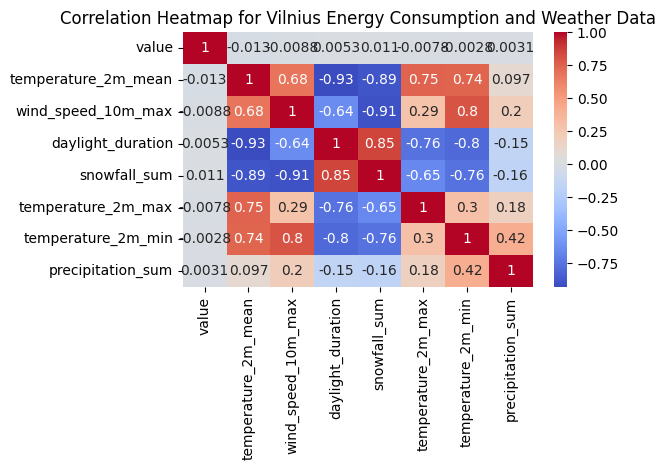

In [ ]:
#create a correlation heatmap (select only numeric columns)
sns.heatmap(df_vilnius_energy.select_dtypes(include=['float64', 'float32']).corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap for Vilnius Energy Consumption and Weather Data')
plt.tight_layout()
plt.show()

#No linear correlarions found between energy consumption and weather data, because correlation values between target variable and weather variables are all below 0.5.
#It happens because energy consumption is influenced by many factors beyond weather, such as economic activity, population behavior, and technological changes.
#Likewise, we have energy consumption data aggregated by half years periods, that is not enough points to establish srong linear correlations
#That is why forecasting models will be built without weather data based on time series analysis. 



In [ ]:
%pip install scikit-learn

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

#RandomForestRegressor model for Vilnius energy consumption as the liner regression did not show good results.
# Prepare features and target for Vilnius
X = df_vilnius_energy.select_dtypes(include=['float64', 'float32']).drop('value', axis=1)
y = df_vilnius_energy['value']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create and train RandomForestRegressor model
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

# Make predictions
y_pred = rf_model.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f'Mean Squared Error: {mse}')
print(f'R² Score: {r2}')

# Feature importance
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

print('\nFeature Importance:')
print(feature_importance)

#The Random Forest regression model failed to produce meaningful predictions for semi-annual electricity consumption. 
# The R² score (~0.00018) shows that the model explains virtually none of the variance, and the high MSE confirms large prediction errors. 
# The main reason is the mismatch between data granularities: electricity consumption is available only twice per year, while weather data is daily, making aggregated weather features weak predictors.


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.
Mean Squared Error: 215065980.25032327
R² Score: 0.00018172125728077582

Feature Importance:
               Feature  Importance
5   temperature_2m_min    0.271484
4   temperature_2m_max    0.165307
6    precipitation_sum    0.164100
1   wind_speed_10m_max    0.134804
0  temperature_2m_mean    0.101651
3         snowfall_sum    0.089366
2    daylight_duration    0.073288
